In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\AIML\Practice\Datasets\Heart Disease\heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
df['trestbps'].describe()

count    861.000000
mean     132.132404
std       19.066070
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

In [5]:
trestbps = df['trestbps'].dropna()
print(trestbps.skew())

0.21333446967212513


In [6]:
df[df['trestbps']<50]['trestbps'].value_counts()

trestbps
0.0    1
Name: count, dtype: int64

In [7]:
df.loc[df['trestbps'] == 0, 'trestbps'] = np.nan

In [8]:
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['trestbps'].describe()

count    920.000000
mean     132.136957
std       17.929761
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

In [9]:
df['chol'].describe()

count    890.000000
mean     199.130337
std      110.780810
min        0.000000
25%      175.000000
50%      223.000000
75%      268.000000
max      603.000000
Name: chol, dtype: float64

In [10]:
(df['chol'] == 0).sum()

np.int64(172)

In [11]:
df.loc[df['chol'] == 0, 'chol'] = np.nan
df['chol'].isna().sum()

np.int64(202)

In [12]:
df['chol'] = df['chol'].fillna(df['chol'].median())
df['chol'].describe()

count    920.000000
mean     245.222826
std       51.785328
min       85.000000
25%      217.750000
50%      239.500000
75%      267.000000
max      603.000000
Name: chol, dtype: float64

In [13]:
df['fbs'].unique()

array([True, False, nan], dtype=object)

In [14]:
df['fbs'].describe()

count       830
unique        2
top       False
freq        692
Name: fbs, dtype: object

In [15]:
df['fbs_missing'] = df["fbs"].isna().astype(int)

In [16]:
df['fbs'] = df['fbs'].astype('boolean')
df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
df['fbs'] = df['fbs'].astype(int)

In [17]:
df['fbs'].head()

0    1
1    0
2    0
3    0
4    0
Name: fbs, dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           920 non-null    int64  
 1   age          920 non-null    int64  
 2   sex          920 non-null    object 
 3   dataset      920 non-null    object 
 4   cp           920 non-null    object 
 5   trestbps     920 non-null    float64
 6   chol         920 non-null    float64
 7   fbs          920 non-null    int64  
 8   restecg      918 non-null    object 
 9   thalch       865 non-null    float64
 10  exang        865 non-null    object 
 11  oldpeak      858 non-null    float64
 12  slope        611 non-null    object 
 13  ca           309 non-null    float64
 14  thal         434 non-null    object 
 15  num          920 non-null    int64  
 16  fbs_missing  920 non-null    int64  
dtypes: float64(5), int64(5), object(7)
memory usage: 122.3+ KB


In [19]:
df['restecg'].unique()

array(['lv hypertrophy', 'normal', 'st-t abnormality', nan], dtype=object)

In [20]:
df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])

In [21]:
df['thalch'].describe()

count    865.000000
mean     137.545665
std       25.926276
min       60.000000
25%      120.000000
50%      140.000000
75%      157.000000
max      202.000000
Name: thalch, dtype: float64

In [22]:
df['thalch'].dropna().skew()

np.float64(-0.2111185807316115)

In [23]:
df['thalch'] = df['thalch'].fillna(df['thalch'].median())

In [24]:
df['exang'].unique()

array([False, True, nan], dtype=object)

In [25]:
df['exang_missing'] = df['exang'].isna().astype(int)

In [26]:
df['exang'] = df['exang'].astype('boolean')
df['exang'] = df['exang'].fillna(df['exang'].mode()[0])
df['exang'] = df['exang'].astype(int)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             920 non-null    int64  
 1   age            920 non-null    int64  
 2   sex            920 non-null    object 
 3   dataset        920 non-null    object 
 4   cp             920 non-null    object 
 5   trestbps       920 non-null    float64
 6   chol           920 non-null    float64
 7   fbs            920 non-null    int64  
 8   restecg        920 non-null    object 
 9   thalch         920 non-null    float64
 10  exang          920 non-null    int64  
 11  oldpeak        858 non-null    float64
 12  slope          611 non-null    object 
 13  ca             309 non-null    float64
 14  thal           434 non-null    object 
 15  num            920 non-null    int64  
 16  fbs_missing    920 non-null    int64  
 17  exang_missing  920 non-null    int64  
dtypes: float64

In [28]:
df['oldpeak'].describe()

count    858.000000
mean       0.878788
std        1.091226
min       -2.600000
25%        0.000000
50%        0.500000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64

In [29]:
(df['oldpeak'] < 0).sum()

np.int64(12)

In [30]:
df[df['oldpeak']<0]['oldpeak'].value_counts()

oldpeak
-1.0    2
-0.5    2
-1.1    1
-1.5    1
-0.1    1
-2.6    1
-0.7    1
-2.0    1
-0.8    1
-0.9    1
Name: count, dtype: int64

In [31]:
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             920 non-null    int64  
 1   age            920 non-null    int64  
 2   sex            920 non-null    object 
 3   dataset        920 non-null    object 
 4   cp             920 non-null    object 
 5   trestbps       920 non-null    float64
 6   chol           920 non-null    float64
 7   fbs            920 non-null    int64  
 8   restecg        920 non-null    object 
 9   thalch         920 non-null    float64
 10  exang          920 non-null    int64  
 11  oldpeak        920 non-null    float64
 12  slope          611 non-null    object 
 13  ca             309 non-null    float64
 14  thal           434 non-null    object 
 15  num            920 non-null    int64  
 16  fbs_missing    920 non-null    int64  
 17  exang_missing  920 non-null    int64  
dtypes: float64

In [33]:
df['slope'].unique()

array(['downsloping', 'flat', 'upsloping', nan], dtype=object)

In [34]:
df['slope'] = df['slope'].fillna('Unknown')
df = pd.get_dummies(df, columns=['slope'], drop_first=True, dtype=int)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 920 non-null    int64  
 1   age                920 non-null    int64  
 2   sex                920 non-null    object 
 3   dataset            920 non-null    object 
 4   cp                 920 non-null    object 
 5   trestbps           920 non-null    float64
 6   chol               920 non-null    float64
 7   fbs                920 non-null    int64  
 8   restecg            920 non-null    object 
 9   thalch             920 non-null    float64
 10  exang              920 non-null    int64  
 11  oldpeak            920 non-null    float64
 12  ca                 309 non-null    float64
 13  thal               434 non-null    object 
 14  num                920 non-null    int64  
 15  fbs_missing        920 non-null    int64  
 16  exang_missing      920 non

In [36]:
df = df.drop(columns=['id', 'ca', 'thal'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                920 non-null    int64  
 1   sex                920 non-null    object 
 2   dataset            920 non-null    object 
 3   cp                 920 non-null    object 
 4   trestbps           920 non-null    float64
 5   chol               920 non-null    float64
 6   fbs                920 non-null    int64  
 7   restecg            920 non-null    object 
 8   thalch             920 non-null    float64
 9   exang              920 non-null    int64  
 10  oldpeak            920 non-null    float64
 11  num                920 non-null    int64  
 12  fbs_missing        920 non-null    int64  
 13  exang_missing      920 non-null    int64  
 14  slope_downsloping  920 non-null    int64  
 15  slope_flat         920 non-null    int64  
 16  slope_upsloping    920 non

In [37]:
df['sex'] = df['sex'].map({"Male": 1, "Female": 0})

In [38]:
df = df.drop(columns=['dataset'])

In [39]:
df['cp'].unique()

array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object)

In [40]:
df['restecg'].unique()

array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object)

In [41]:
df = pd.get_dummies(df, columns=["cp", "restecg"], drop_first=True, dtype=int)

In [42]:
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   sex                       920 non-null    int64  
 2   trestbps                  920 non-null    float64
 3   chol                      920 non-null    float64
 4   fbs                       920 non-null    int64  
 5   thalch                    920 non-null    float64
 6   exang                     920 non-null    int64  
 7   oldpeak                   920 non-null    float64
 8   fbs_missing               920 non-null    int64  
 9   exang_missing             920 non-null    int64  
 10  slope_downsloping         920 non-null    int64  
 11  slope_flat                920 non-null    int64  
 12  slope_upsloping           920 non-null    int64  
 13  cp_atypical angina        920 non-null    int64  
 14  cp_non-ang

In [43]:
x = df.drop("target", axis=1)
y = df['target']

In [44]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [45]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,4,5,6,8,10],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,5,10]
}

dt = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(
    estimator=dt,
    param_grid = param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Score: 0.7676778819635962


In [46]:
model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=1,
    min_samples_split=10,
    random_state=42
)
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
y_pred = model.predict(x_test)

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7934782608695652
Precision: 0.7711864406779662
Recall 0.8921568627450981
F1 score: 0.8272727272727273

Confusion Matrix:
 [[55 27]
 [11 91]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.67      0.74        82
           1       0.77      0.89      0.83       102

    accuracy                           0.79       184
   macro avg       0.80      0.78      0.79       184
weighted avg       0.80      0.79      0.79       184



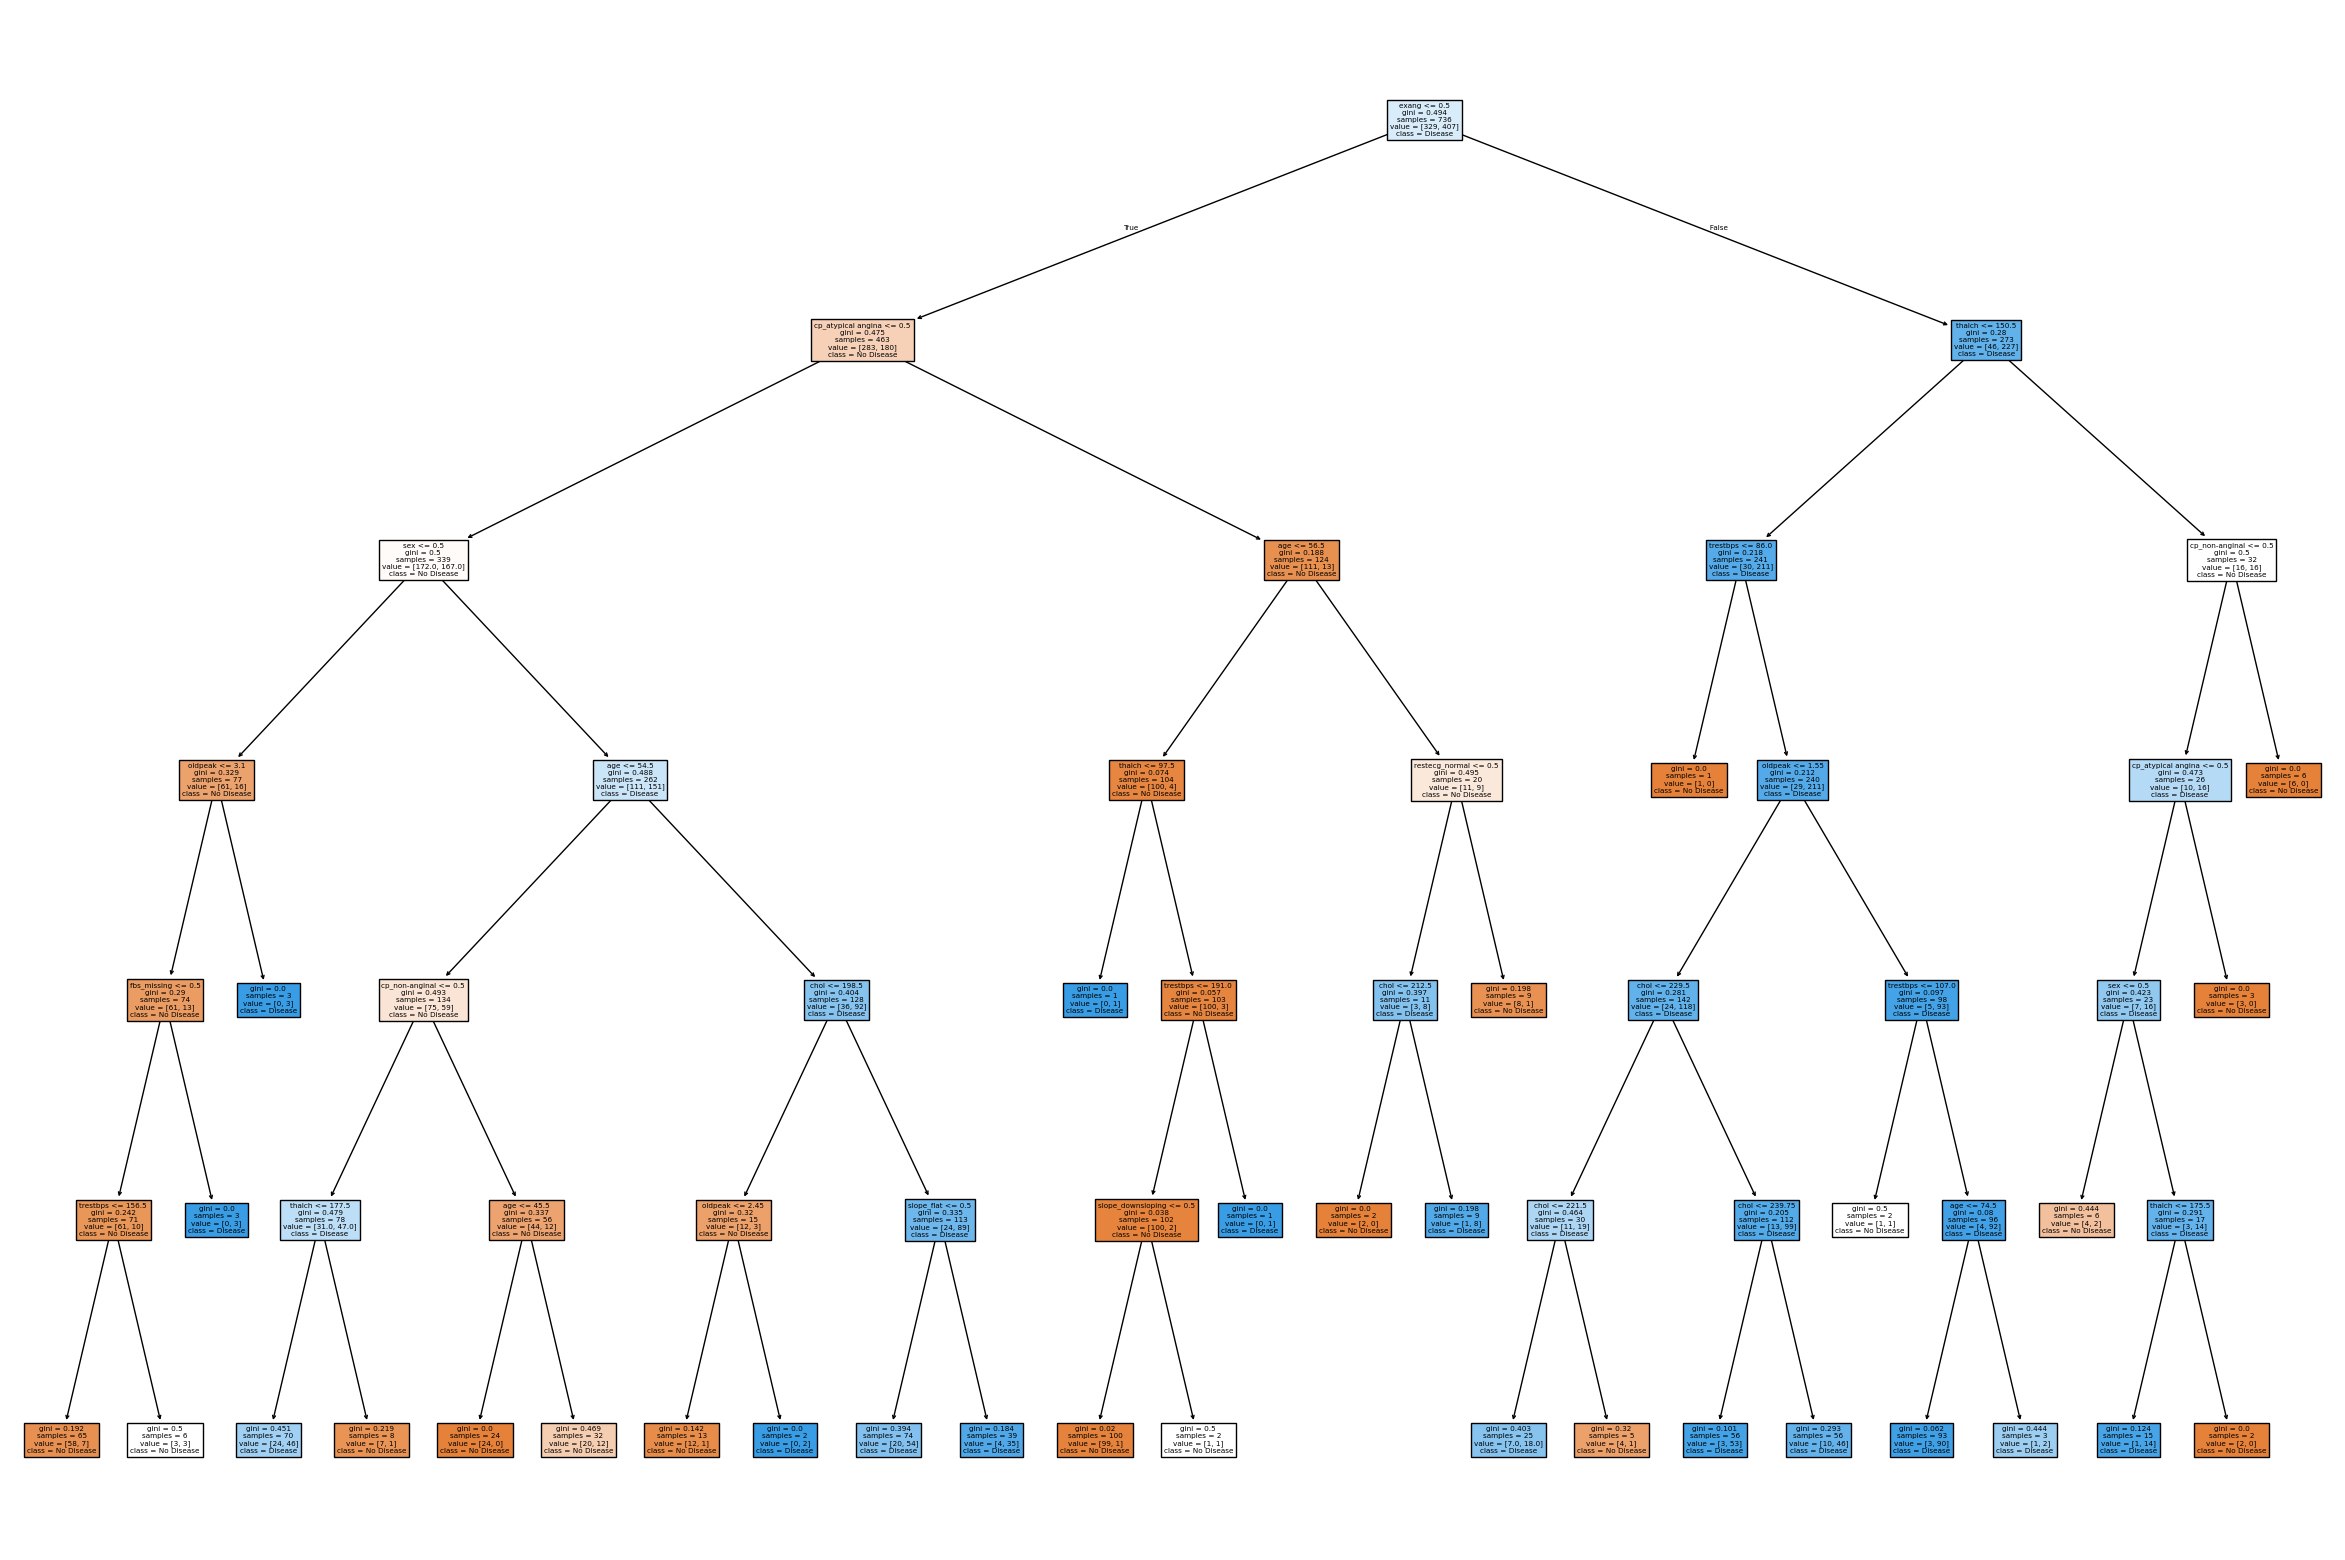

In [49]:
plt.figure(figsize=(30, 20))
plot_tree(model, feature_names=x.columns, class_names=["No Disease", "Disease"], filled=True)
plt.show()

In [50]:
from joblib import dump

dump(model, r'C:\Users\HP\OneDrive\Desktop\AIML\Practice\Datasets\Heart Disease\heart_disease_model.joblib')

feature_names = x.columns.tolist()
dump(feature_names, r'C:\Users\HP\OneDrive\Desktop\AIML\Practice\Datasets\Heart Disease\feature_names.joblib')

print("Model saved as heart_disease_model.joblib")
print("Feature names saved as feature_names.joblib")
print(feature_names)

Model saved as heart_disease_model.joblib
Feature names saved as feature_names.joblib
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'fbs_missing', 'exang_missing', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality']
